In [2]:
import pandas as pd

PRB_data = pd.read_csv('traffic_DLPRB.csv')
PRB_data = PRB_data.drop(PRB_data.columns[0], axis=1)  # Drop the first column if it's an index or unnecessary
PRB_data.head()

,0_0_0,0_0_1,0_0_2,0_0_3,0_0_4,0_0_5,0_0_6,0_0_7,0_0_8,0_0_9,...,29_2_22,29_2_23,29_2_24,29_2_25,29_2_26,29_2_27,29_2_28,29_2_29,29_2_30,29_2_31
0,0.066698,0.085882,0.000000,0.090813,0.214019,0.317046,0.164410,0.000000,0.455932,0.149637,...,0.013303,0.000000,0.000000,0.000000,0.000000,0.123099,0.000000,0.054892,0.123654,0.057741
1,0.138920,0.256273,0.257673,0.026058,0.000000,0.151237,0.166434,0.039496,0.000000,0.000000,...,0.101364,0.044955,0.205873,0.038444,0.000000,0.107314,0.294831,0.000000,0.101475,0.056402
2,0.158870,0.000000,0.136742,0.207859,0.000000,0.009139,0.000000,0.000000,0.117079,0.000000,...,0.149791,0.009632,0.000000,0.000000,0.053097,0.000000,0.000000,0.144061,0.241812,0.165295
3,0.019840,0.000000,0.175130,0.000000,0.044551,0.000000,0.000000,0.207104,0.000000,0.055919,...,0.190656,0.000000,0.110855,0.000000,0.114978,0.090578,0.000000,0.037659,0.200538,0.111626
4,0.087727,0.152698,0.065651,0.020144,0.000000,0.111326,0.318864,0.000000,0.199769,0.054351,...,0.454085,0.000000,0.009313,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106244


In [3]:
cell_cols = {}
for col in PRB_data.columns:
    parts = col.split('_')
    bs, cell, beam = parts[0], parts[1], parts[2]
    key = f"{bs}_{cell}"
    cell_cols.setdefault(key, []).append(col)

# Sum beams for each cell
cell_data = {}
for cell_key, cols in cell_cols.items():
    cell_data[cell_key] = PRB_data[cols].sum(axis=1)

cell_PRB_df = pd.DataFrame(cell_data)

# Relabel columns to C1, C2, ... C90
cell_PRB_df.columns = [f"C{i+1}" for i in range(len(cell_PRB_df.columns))]

In [4]:
cell_PRB_df.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,3.597879,2.263070,2.536997,1.767760,1.861057,1.922795,2.927855,2.055274,2.617039,2.560400,...,1.215159,0.650592,1.304670,1.603881,2.229107,2.191400,1.295968,1.808825,1.598069,2.252928
1,2.804197,1.845998,2.420828,1.637078,1.171218,1.946756,2.292398,1.396858,1.786607,2.391954,...,2.659069,1.256097,2.051581,1.603982,2.596555,1.418913,1.276000,3.883666,1.842837,1.937998
2,1.854696,2.361856,1.836115,1.799294,2.031284,1.891162,1.712333,1.115131,3.026528,1.796631,...,1.608693,1.408412,1.851250,1.730058,3.029380,2.378878,1.604257,1.473055,1.840397,1.910943
3,2.074821,1.934856,4.769888,2.592996,8.567154,8.421780,2.304716,3.221027,10.187385,2.593069,...,2.121308,2.417024,8.823012,5.306943,6.314380,1.632400,2.896760,4.669593,5.848477,2.307870
4,2.673236,5.798783,3.702238,3.698515,9.849255,9.479258,3.378446,4.815367,7.196895,1.694802,...,1.948843,5.882658,6.874128,6.532096,6.119528,2.530514,1.694510,2.770702,4.879375,1.902079


In [5]:
# divide each cell by 32 since each cell has 32 beams
cell_PRB_df = cell_PRB_df / 32
cell_PRB_df.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,0.112434,0.070721,0.079281,0.055243,0.058158,0.060087,0.091495,0.064227,0.081782,0.080012,...,0.037974,0.020331,0.040771,0.050121,0.069660,0.068481,0.040499,0.056526,0.049940,0.070404
1,0.087631,0.057687,0.075651,0.051159,0.036601,0.060836,0.071637,0.043652,0.055831,0.074749,...,0.083096,0.039253,0.064112,0.050124,0.081142,0.044341,0.039875,0.121365,0.057589,0.060562
2,0.057959,0.073808,0.057379,0.056228,0.063478,0.059099,0.053510,0.034848,0.094579,0.056145,...,0.050272,0.044013,0.057852,0.054064,0.094668,0.074340,0.050133,0.046033,0.057512,0.059717
3,0.064838,0.060464,0.149059,0.081031,0.267724,0.263181,0.072022,0.100657,0.318356,0.081033,...,0.066291,0.075532,0.275719,0.165842,0.197324,0.051012,0.090524,0.145925,0.182765,0.072121
4,0.083539,0.181212,0.115695,0.115579,0.307789,0.296227,0.105576,0.150480,0.224903,0.052963,...,0.060901,0.183833,0.214816,0.204128,0.191235,0.079079,0.052953,0.086584,0.152480,0.059440


In [6]:

import matplotlib.pyplot as plt
import numpy as np

def plot_daily_pattern(df, cell="C1"):
    traffic = df[cell].values.reshape(-1, 24)
    plt.figure(figsize=(12,6))
    for day in range(traffic.shape[0]):
        week = day // 7 + 1
        day_of_week = day % 7 + 1

        plt.plot(
            np.arange(24),
            traffic[day],
            label=f"W{week}-D{day_of_week}",
            alpha=0.8
        )

    plt.xticks(range(24))
    plt.xlabel("Hour of Day")
    plt.ylabel("Average PRB Utilization")
    plt.title(f"Daily Traffic Pattern - {cell}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


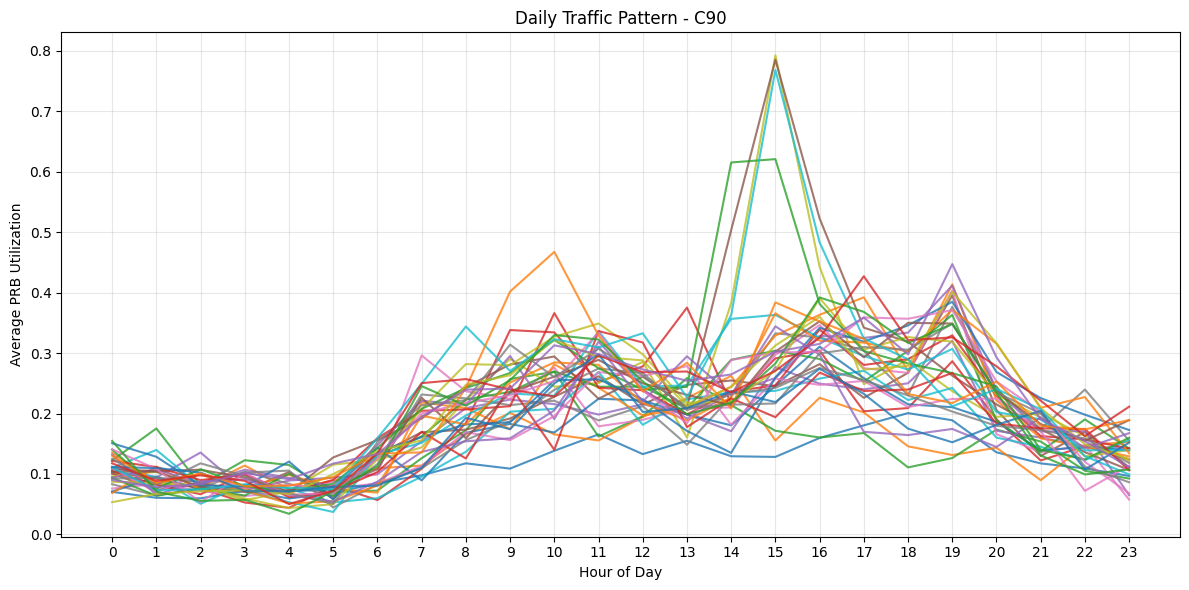

In [7]:
plot_daily_pattern(cell_PRB_df, "C90")

In [8]:
# add a row below column name for cell types, where the value is the cell type for each cell.

cell_types = {
'C1': 'Shop',
'C2': 'Shop',
'C3': 'Transport',
'C4': 'Shop',
'C5': 'Shop',
'C6': 'Shop',
'C7': 'Hospital',
'C8': 'Rush',
'C9': 'Rush',
'C10': 'Rush',
'C11': 'Rush',
'C12': 'Shop',
'C13': 'House',
'C14': 'Rush',
'C15': 'House',
'C16': 'Transport',
'C17': 'Shop',
'C18': 'Rush',
'C19': 'Shop',
'C20': 'Shop',
'C21': 'House',
'C22': 'Shop',
'C23': 'Rush',
'C24': 'House',
'C25': 'Transport',
'C26': 'Shop',
'C27': 'Hospital',
'C28': 'Shop',
'C29': 'Rush',
'C30': 'Rush',
'C31': 'Rush',
'C32': 'Rush',
'C33': 'Hospital',
'C34': 'Rush',
'C35': 'Transport',
'C36': 'Rush',
'C37': 'Shop',
'C38': 'House',
'C39': 'Shop',
'C40': 'Hospital',
'C41': 'Hospital',
'C42': 'House',
'C43': 'Shop',
'C44': 'Rush',
'C45': 'Rush',
'C46': 'House',
'C47': 'Shop',
'C48': 'Shop',
'C49': 'Rush',
'C50': 'Transport',
'C51': 'Shop',
'C52': 'House',
'C53': 'Rush',
'C54': 'Shop',
'C55': 'Transport',
'C56': 'Rush',
'C57': 'Shop',
'C58': 'Rush',
'C59': 'Shop',
'C60': 'House',
'C61': 'Shop',
'C62': 'Shop',
'C63': 'House',
'C64': 'Rush',
'C65': 'Rush',
'C66': 'Rush',
'C67': 'Rush',
'C68': 'Hospital',
'C69': 'House',
'C70': 'House',
'C71': 'House',
'C72': 'House',
'C73': 'Rush',
'C74': 'Shop',
'C75': 'Rush',
'C76': 'Shop',
'C77': 'House',
'C78': 'House',
'C79': 'Rush',
'C80': 'Rush',
'C81': 'Shop',
'C82': 'House',
'C83': 'House',
'C84': 'House',
'C85': 'Rush',
'C86': 'Shop',
'C87': 'Rush',
'C88': 'Shop',
'C89': 'Shop',
'C90': 'Rush'}

In [9]:
# for each cell in cell_PRB_df, add a row below the column name with the corresponding cell type from cell_types

cell_PRB_df.loc['Cell Type'] = [cell_types.get(col, 'Unknown') for col in cell_PRB_df.columns]
cell_PRB_df

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,0.112434,0.070721,0.079281,0.055243,0.058158,0.060087,0.091495,0.064227,0.081782,0.080012,...,0.037974,0.020331,0.040771,0.050121,0.06966,0.068481,0.040499,0.056526,0.04994,0.070404
1,0.087631,0.057687,0.075651,0.051159,0.036601,0.060836,0.071637,0.043652,0.055831,0.074749,...,0.083096,0.039253,0.064112,0.050124,0.081142,0.044341,0.039875,0.121365,0.057589,0.060562
2,0.057959,0.073808,0.057379,0.056228,0.063478,0.059099,0.05351,0.034848,0.094579,0.056145,...,0.050272,0.044013,0.057852,0.054064,0.094668,0.07434,0.050133,0.046033,0.057512,0.059717
3,0.064838,0.060464,0.149059,0.081031,0.267724,0.263181,0.072022,0.100657,0.318356,0.081033,...,0.066291,0.075532,0.275719,0.165842,0.197324,0.051012,0.090524,0.145925,0.182765,0.072121
4,0.083539,0.181212,0.115695,0.115579,0.307789,0.296227,0.105576,0.15048,0.224903,0.052963,...,0.060901,0.183833,0.214816,0.204128,0.191235,0.079079,0.052953,0.086584,0.15248,0.05944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,0.673875,0.485778,1.373865,0.695428,0.986002,0.740937,0.052591,0.06689,0.045989,0.465358,...,0.215457,0.728822,1.253267,0.723007,0.638299,0.161379,0.437661,1.107072,1.229684,0.292928
837,0.660321,0.460766,1.355883,0.703727,1.098238,0.90619,0.034915,0.046161,0.064893,0.234108,...,0.170222,0.54542,1.019439,0.627449,0.567029,0.355374,0.303613,0.967276,1.10406,0.190635
838,0.480069,0.433437,0.945571,0.72469,0.902131,0.822629,0.064928,0.052868,0.040487,0.135894,...,0.130069,0.415453,1.082592,0.562452,0.524091,0.062059,0.188774,0.746108,1.064501,0.154372
839,0.355559,0.437763,0.76455,0.511937,0.861371,0.69642,0.047257,0.083071,0.168241,0.108849,...,0.144755,0.367288,0.834728,0.589053,0.265899,0.076198,0.16577,0.653761,0.923225,0.111248


In [10]:
# Move the 'Cell Type' row to the top of the DataFrame
cell_PRB_df = pd.concat([cell_PRB_df.loc[['Cell Type']], cell_PRB_df.drop('Cell Type')])
cell_PRB_df
      

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
Cell Type,Shop,Shop,Transport,Shop,Shop,Shop,Hospital,Rush,Rush,Rush,...,Shop,House,House,House,Rush,Shop,Rush,Shop,Shop,Rush
0,0.112434,0.070721,0.079281,0.055243,0.058158,0.060087,0.091495,0.064227,0.081782,0.080012,...,0.037974,0.020331,0.040771,0.050121,0.06966,0.068481,0.040499,0.056526,0.04994,0.070404
1,0.087631,0.057687,0.075651,0.051159,0.036601,0.060836,0.071637,0.043652,0.055831,0.074749,...,0.083096,0.039253,0.064112,0.050124,0.081142,0.044341,0.039875,0.121365,0.057589,0.060562
2,0.057959,0.073808,0.057379,0.056228,0.063478,0.059099,0.05351,0.034848,0.094579,0.056145,...,0.050272,0.044013,0.057852,0.054064,0.094668,0.07434,0.050133,0.046033,0.057512,0.059717
3,0.064838,0.060464,0.149059,0.081031,0.267724,0.263181,0.072022,0.100657,0.318356,0.081033,...,0.066291,0.075532,0.275719,0.165842,0.197324,0.051012,0.090524,0.145925,0.182765,0.072121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,0.84863,0.516517,1.69494,0.785925,1.048566,0.725522,0.044044,0.076199,0.0815,0.570077,...,0.297412,0.719494,1.404993,0.652497,0.898523,0.108257,0.480978,1.623032,1.516566,0.44724
836,0.673875,0.485778,1.373865,0.695428,0.986002,0.740937,0.052591,0.06689,0.045989,0.465358,...,0.215457,0.728822,1.253267,0.723007,0.638299,0.161379,0.437661,1.107072,1.229684,0.292928
837,0.660321,0.460766,1.355883,0.703727,1.098238,0.90619,0.034915,0.046161,0.064893,0.234108,...,0.170222,0.54542,1.019439,0.627449,0.567029,0.355374,0.303613,0.967276,1.10406,0.190635
838,0.480069,0.433437,0.945571,0.72469,0.902131,0.822629,0.064928,0.052868,0.040487,0.135894,...,0.130069,0.415453,1.082592,0.562452,0.524091,0.062059,0.188774,0.746108,1.064501,0.154372


In [11]:
#in the second row can you rename every name with a number like shop1, shop2, transport1, transport2, etc.

for cell_type in cell_types.values():
    count = 1
    for col in cell_PRB_df.columns:
        if cell_PRB_df.at['Cell Type', col] == cell_type:
            cell_PRB_df.at['Cell Type', col] = f"{cell_type}{count}"
            count += 1

cell_PRB_df




,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
Cell Type,Shop1,Shop2,Transport1,Shop3,Shop4,Shop5,Hospital1,Rush1,Rush2,Rush3,...,Shop26,House17,House18,House19,Rush28,Shop27,Rush29,Shop28,Shop29,Rush30
0,0.112434,0.070721,0.079281,0.055243,0.058158,0.060087,0.091495,0.064227,0.081782,0.080012,...,0.037974,0.020331,0.040771,0.050121,0.06966,0.068481,0.040499,0.056526,0.04994,0.070404
1,0.087631,0.057687,0.075651,0.051159,0.036601,0.060836,0.071637,0.043652,0.055831,0.074749,...,0.083096,0.039253,0.064112,0.050124,0.081142,0.044341,0.039875,0.121365,0.057589,0.060562
2,0.057959,0.073808,0.057379,0.056228,0.063478,0.059099,0.05351,0.034848,0.094579,0.056145,...,0.050272,0.044013,0.057852,0.054064,0.094668,0.07434,0.050133,0.046033,0.057512,0.059717
3,0.064838,0.060464,0.149059,0.081031,0.267724,0.263181,0.072022,0.100657,0.318356,0.081033,...,0.066291,0.075532,0.275719,0.165842,0.197324,0.051012,0.090524,0.145925,0.182765,0.072121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,0.84863,0.516517,1.69494,0.785925,1.048566,0.725522,0.044044,0.076199,0.0815,0.570077,...,0.297412,0.719494,1.404993,0.652497,0.898523,0.108257,0.480978,1.623032,1.516566,0.44724
836,0.673875,0.485778,1.373865,0.695428,0.986002,0.740937,0.052591,0.06689,0.045989,0.465358,...,0.215457,0.728822,1.253267,0.723007,0.638299,0.161379,0.437661,1.107072,1.229684,0.292928
837,0.660321,0.460766,1.355883,0.703727,1.098238,0.90619,0.034915,0.046161,0.064893,0.234108,...,0.170222,0.54542,1.019439,0.627449,0.567029,0.355374,0.303613,0.967276,1.10406,0.190635
838,0.480069,0.433437,0.945571,0.72469,0.902131,0.822629,0.064928,0.052868,0.040487,0.135894,...,0.130069,0.415453,1.082592,0.562452,0.524091,0.062059,0.188774,0.746108,1.064501,0.154372


In [12]:
# remove the C1, C2...as comuln names and make cell types as column names instead since its all unique

cell_PRB_df.columns = cell_PRB_df.loc['Cell Type']

# Remove row 1
cell_PRB_df = cell_PRB_df.drop('Cell Type')
cell_PRB_df

Cell Type,Shop1,Shop2,Transport1,Shop3,Shop4,Shop5,Hospital1,Rush1,Rush2,Rush3,...,Shop26,House17,House18,House19,Rush28,Shop27,Rush29,Shop28,Shop29,Rush30
0,0.112434,0.070721,0.079281,0.055243,0.058158,0.060087,0.091495,0.064227,0.081782,0.080012,...,0.037974,0.020331,0.040771,0.050121,0.06966,0.068481,0.040499,0.056526,0.04994,0.070404
1,0.087631,0.057687,0.075651,0.051159,0.036601,0.060836,0.071637,0.043652,0.055831,0.074749,...,0.083096,0.039253,0.064112,0.050124,0.081142,0.044341,0.039875,0.121365,0.057589,0.060562
2,0.057959,0.073808,0.057379,0.056228,0.063478,0.059099,0.05351,0.034848,0.094579,0.056145,...,0.050272,0.044013,0.057852,0.054064,0.094668,0.07434,0.050133,0.046033,0.057512,0.059717
3,0.064838,0.060464,0.149059,0.081031,0.267724,0.263181,0.072022,0.100657,0.318356,0.081033,...,0.066291,0.075532,0.275719,0.165842,0.197324,0.051012,0.090524,0.145925,0.182765,0.072121
4,0.083539,0.181212,0.115695,0.115579,0.307789,0.296227,0.105576,0.15048,0.224903,0.052963,...,0.060901,0.183833,0.214816,0.204128,0.191235,0.079079,0.052953,0.086584,0.15248,0.05944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,0.84863,0.516517,1.69494,0.785925,1.048566,0.725522,0.044044,0.076199,0.0815,0.570077,...,0.297412,0.719494,1.404993,0.652497,0.898523,0.108257,0.480978,1.623032,1.516566,0.44724
836,0.673875,0.485778,1.373865,0.695428,0.986002,0.740937,0.052591,0.06689,0.045989,0.465358,...,0.215457,0.728822,1.253267,0.723007,0.638299,0.161379,0.437661,1.107072,1.229684,0.292928
837,0.660321,0.460766,1.355883,0.703727,1.098238,0.90619,0.034915,0.046161,0.064893,0.234108,...,0.170222,0.54542,1.019439,0.627449,0.567029,0.355374,0.303613,0.967276,1.10406,0.190635
838,0.480069,0.433437,0.945571,0.72469,0.902131,0.822629,0.064928,0.052868,0.040487,0.135894,...,0.130069,0.415453,1.082592,0.562452,0.524091,0.062059,0.188774,0.746108,1.064501,0.154372


In [13]:
# save as a csv file
cell_PRB_df.to_csv('cell_type_labelled_data_PRB.csv', index=False)

In [15]:
# do the same for the file traffic_MR_number.csv
MR_data = pd.read_csv('traffic_MR_number.csv')
MR_data = MR_data.drop(MR_data.columns[0], axis=1)  # Drop the first column if it's an index or unnecessary
MR_data.head()


,0_0_0,0_0_1,0_0_2,0_0_3,0_0_4,0_0_5,0_0_6,0_0_7,0_0_8,0_0_9,...,29_2_22,29_2_23,29_2_24,29_2_25,29_2_26,29_2_27,29_2_28,29_2_29,29_2_30,29_2_31
0,0.000000,0.000000,0.000000,0.027642,0.055997,0.0,0.000000,0.000000,0.016494,0.000000,...,0.132844,0.000000,0.000000,0.197986,0.057834,0.000000,0.054223,0.000000,0.000000,0.000000
1,0.000000,0.152042,0.000000,0.000000,0.000000,0.0,0.010041,0.000000,0.000000,0.103261,...,0.000000,0.000000,0.000000,0.200403,0.114988,0.000000,0.000000,0.000000,0.000000,0.131941
2,0.173515,0.227844,0.000000,0.007925,0.000000,0.0,0.056169,0.000000,0.167527,0.000000,...,0.000000,0.005662,0.000000,0.158079,0.000000,0.085078,0.236631,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.030259,0.010449,0.098800,0.0,0.000000,0.000000,0.286327,0.000000,...,0.158921,0.074785,0.000000,0.000000,0.217637,0.031042,0.000000,0.145658,0.046112,0.181847
4,0.062068,0.000000,0.179430,0.000000,0.184392,0.0,0.244443,0.078096,0.079690,0.251222,...,0.137332,0.000000,0.350005,0.000000,0.021422,0.195442,0.114019,0.111869,0.000000,0.042406


In [16]:
cell_cols = {}
for col in MR_data.columns:
    parts = col.split('_')
    bs, cell, beam = parts[0], parts[1], parts[2]
    key = f"{bs}_{cell}"
    cell_cols.setdefault(key, []).append(col)

# Sum beams for each cell
cell_data = {}
for cell_key, cols in cell_cols.items():
    cell_data[cell_key] = MR_data[cols].sum(axis=1)

cell_MR_df = pd.DataFrame(cell_data)

# Relabel columns to C1, C2, ... C90
cell_MR_df.columns = [f"C{i+1}" for i in range(len(cell_MR_df.columns))]

In [17]:
# divide each cell by 32 since each cell has 32 beams
cell_MR_df = cell_MR_df / 32
cell_MR_df.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,0.051531,0.039483,0.038949,0.045097,0.067538,0.058568,0.056984,0.063342,0.044976,0.049888,...,0.054386,0.086873,0.051286,0.066168,0.078301,0.077322,0.043556,0.038423,0.079982,0.047946
1,0.046718,0.074665,0.030432,0.060481,0.051553,0.061826,0.053073,0.045558,0.075896,0.078340,...,0.053249,0.067949,0.059669,0.047649,0.048508,0.047921,0.068875,0.063286,0.044254,0.039146
2,0.068255,0.092592,0.061597,0.030301,0.068638,0.060319,0.060015,0.073936,0.051154,0.075533,...,0.054537,0.046133,0.052642,0.058186,0.052217,0.098732,0.055005,0.047841,0.050479,0.035267
3,0.079129,0.163879,0.226734,0.154912,0.362841,0.249520,0.131184,0.160355,0.687514,0.067997,...,0.083799,0.090486,0.336733,0.256517,0.246297,0.090336,0.082968,0.151981,0.305651,0.104029
4,0.082628,0.197760,0.186961,0.213029,0.400073,0.244590,0.138129,0.208021,0.459493,0.087712,...,0.072032,0.119058,0.305559,0.225991,0.254465,0.037464,0.092769,0.128242,0.254277,0.078185


In [19]:
cell_MR_df.loc['Cell Type'] = [cell_types.get(col, 'Unknown') for col in cell_MR_df.columns]
cell_MR_df

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,0.051531,0.039483,0.038949,0.045097,0.067538,0.058568,0.056984,0.063342,0.044976,0.049888,...,0.054386,0.086873,0.051286,0.066168,0.078301,0.077322,0.043556,0.038423,0.079982,0.047946
1,0.046718,0.074665,0.030432,0.060481,0.051553,0.061826,0.053073,0.045558,0.075896,0.07834,...,0.053249,0.067949,0.059669,0.047649,0.048508,0.047921,0.068875,0.063286,0.044254,0.039146
2,0.068255,0.092592,0.061597,0.030301,0.068638,0.060319,0.060015,0.073936,0.051154,0.075533,...,0.054537,0.046133,0.052642,0.058186,0.052217,0.098732,0.055005,0.047841,0.050479,0.035267
3,0.079129,0.163879,0.226734,0.154912,0.362841,0.24952,0.131184,0.160355,0.687514,0.067997,...,0.083799,0.090486,0.336733,0.256517,0.246297,0.090336,0.082968,0.151981,0.305651,0.104029
4,0.082628,0.19776,0.186961,0.213029,0.400073,0.24459,0.138129,0.208021,0.459493,0.087712,...,0.072032,0.119058,0.305559,0.225991,0.254465,0.037464,0.092769,0.128242,0.254277,0.078185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,0.779184,0.577948,1.368049,0.705394,1.066759,0.735214,0.099014,0.044952,0.052215,0.396512,...,0.210273,0.644967,1.575758,0.752718,0.680341,0.097948,0.472466,1.223184,1.231968,0.303625
837,0.648625,0.530832,1.287434,0.612399,0.941301,0.792553,0.058608,0.051041,0.062989,0.272309,...,0.176681,0.585935,1.213857,0.629559,0.721643,0.144477,0.405699,0.988058,1.096842,0.161793
838,0.547402,0.434602,1.218986,0.562758,0.78667,0.707431,0.048456,0.045948,0.072744,0.188139,...,0.150923,0.492766,1.060584,0.591182,0.519614,0.05694,0.294473,0.781692,0.927349,0.183144
839,0.453158,0.434516,1.001354,0.503202,0.779039,0.528903,0.076699,0.094046,0.118122,0.141197,...,0.159722,0.367707,0.893569,0.463456,0.335754,0.097724,0.163822,0.697749,0.882777,0.103553


In [20]:
cell_MR_df = pd.concat([cell_MR_df.loc[['Cell Type']], cell_MR_df.drop('Cell Type')])


for cell_type in cell_types.values():
    count = 1
    for col in cell_MR_df.columns:
        if cell_MR_df.at['Cell Type', col] == cell_type:
            cell_MR_df.at['Cell Type', col] = f"{cell_type}{count}"
            count += 1


cell_MR_df.columns = cell_MR_df.loc['Cell Type']

# Remove row 1
cell_MR_df = cell_MR_df.drop('Cell Type')
cell_MR_df

Cell Type,Shop1,Shop2,Transport1,Shop3,Shop4,Shop5,Hospital1,Rush1,Rush2,Rush3,...,Shop26,House17,House18,House19,Rush28,Shop27,Rush29,Shop28,Shop29,Rush30
0,0.051531,0.039483,0.038949,0.045097,0.067538,0.058568,0.056984,0.063342,0.044976,0.049888,...,0.054386,0.086873,0.051286,0.066168,0.078301,0.077322,0.043556,0.038423,0.079982,0.047946
1,0.046718,0.074665,0.030432,0.060481,0.051553,0.061826,0.053073,0.045558,0.075896,0.07834,...,0.053249,0.067949,0.059669,0.047649,0.048508,0.047921,0.068875,0.063286,0.044254,0.039146
2,0.068255,0.092592,0.061597,0.030301,0.068638,0.060319,0.060015,0.073936,0.051154,0.075533,...,0.054537,0.046133,0.052642,0.058186,0.052217,0.098732,0.055005,0.047841,0.050479,0.035267
3,0.079129,0.163879,0.226734,0.154912,0.362841,0.24952,0.131184,0.160355,0.687514,0.067997,...,0.083799,0.090486,0.336733,0.256517,0.246297,0.090336,0.082968,0.151981,0.305651,0.104029
4,0.082628,0.19776,0.186961,0.213029,0.400073,0.24459,0.138129,0.208021,0.459493,0.087712,...,0.072032,0.119058,0.305559,0.225991,0.254465,0.037464,0.092769,0.128242,0.254277,0.078185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,0.849837,0.620692,1.46991,0.735591,1.164845,0.834122,0.072845,0.055177,0.056673,0.540973,...,0.358485,0.699946,1.624321,0.75299,0.866967,0.119439,0.564328,1.688871,1.426037,0.47046
836,0.779184,0.577948,1.368049,0.705394,1.066759,0.735214,0.099014,0.044952,0.052215,0.396512,...,0.210273,0.644967,1.575758,0.752718,0.680341,0.097948,0.472466,1.223184,1.231968,0.303625
837,0.648625,0.530832,1.287434,0.612399,0.941301,0.792553,0.058608,0.051041,0.062989,0.272309,...,0.176681,0.585935,1.213857,0.629559,0.721643,0.144477,0.405699,0.988058,1.096842,0.161793
838,0.547402,0.434602,1.218986,0.562758,0.78667,0.707431,0.048456,0.045948,0.072744,0.188139,...,0.150923,0.492766,1.060584,0.591182,0.519614,0.05694,0.294473,0.781692,0.927349,0.183144


In [21]:
# export to csv

cell_MR_df.to_csv('cell_type_labelled_data_MR.csv', index=False)